# Figure making code for `pinn-v2`

In [1]:
import sys
sys.path.append('../src')

import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

import matplotlib.pyplot as plt
plt.style.core.USER_LIBRARY_PATHS.append('/gscratch/matsulab/utils/ctleelab-mpl-utilities/ctleelab_plothelper')
plt.style.reload_library()

sys.path.append('../../../utils')
from fonts.mpl_fonts import set_arial_font
set_arial_font()

[mpl_fonts] Using font: Arial
[mpl_fonts] Font dir: /mmfs1/gscratch/matsulab/utils/fonts


In [87]:
## To reload

import importlib
# import pinn.plot as plot
import data_generation.preprocess as preprocess
# import pinn.utils as utils
# import pinn.analysis as analysis
# import pinn.normal_curves as normal

# importlib.reload(plot)
# importlib.reload(utils)
importlib.reload(preprocess)
# importlib.reload(analysis)
# importlib.reload(normal)

<module 'data_generation.preprocess' from '/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/notebooks/../src/data_generation/preprocess.py'>

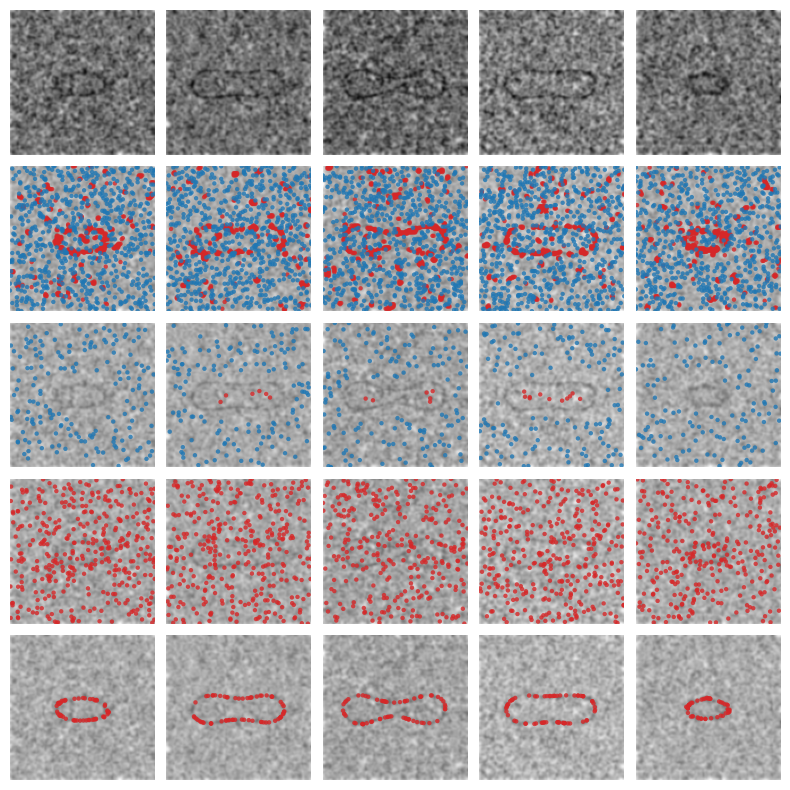

In [5]:
## FIGURE 2B (Input Images)

import os
import numpy as np
import matplotlib.pyplot as plt
from pinn.cryoet_io import load_mrc_data
from data_generation.preprocess import overlay_points_on_cryoet_ax
from pinn.utils import load_pts_data
from pinn.plot import show_cryoet_slice

import mrcfile
import jax
import jax.numpy as jnp

# ==== Parameters =====
GRID_SIZE = 128
shape = "biconcave"
additive = 0.1
missing  = 0.7
str_add = f"{additive:.2f}".replace('.', '')
str_miss = f"{missing:.1f}".replace('.', '')
lambda_1 = 100000
lambda_2 = 1
lambda_3 = 100000

slice_index_list = [24, 44, 64, 84, 104]
axis = "z"
pts_size=10

# ==== Load point data =====
pts_path = f"../data/synthetic/pts"
edge = load_pts_data(f"{pts_path}/edge/e_{shape}_a{str_add}_m{str_miss}_g{GRID_SIZE}.npz", perm=(0,1,2))
sign = load_pts_data(f"{pts_path}/sign/s_{shape}.npz", perm=(0,1,2))
phys = load_pts_data(f"{pts_path}/phys/p_{shape}.npz", perm=(0,1,2))
curv = load_pts_data(f"{pts_path}/curv/a{str_add}_m{str_miss}_g{GRID_SIZE}/c_{shape}_{lambda_1}_{lambda_2}_{lambda_3}.npz", perm=(0,1,2))

# ==== Load CryoET data =====
mrc_file_path = f"../data/synthetic/mrc/{shape}_a{str_add}_m{str_miss}.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)

n_col = len(slice_index_list)
n_row = 5
fig = plt.figure(figsize=(2*n_col, 2*n_row))

fig.subplots_adjust(
    wspace=0.05,   # width space (fraction of axes)
    hspace=0.08,   # height space
)

plt.style.reload_library()
with plt.style.context(["base", "transparent"]):

    # Row 1: 
    for i, slice in enumerate(slice_index_list):
        ax = fig.add_subplot(n_row, n_col, i+1)
        overlay_points_on_cryoet_ax(ax, cryoet=cryoET_data, axis=axis, slice_index=slice)

    # Row 2:
    for i, slice in enumerate(slice_index_list):
        ax = fig.add_subplot(n_row, n_col, 1*n_col+i+1)
        pt_e = edge["points"][edge["label"] == 1][:, [2, 0, 1]]
        pt_b = edge["points"][edge["label"] == 0][:, [2, 0, 1]]
        overlays = [
            {"data": pt_e, "label": "Edge", "color": "tab:red"},
            {"data": pt_b, "label": "Bulk", "color": "tab:blue"},
        ]
        overlay_points_on_cryoet_ax(ax, cryoet=cryoET_data, overlays=overlays, axis=axis, slice_index=slice, pts_size=pts_size, cryo_alpha=0.6)

    # Row 3:
    for i, slice in enumerate(slice_index_list):
        ax = fig.add_subplot(n_row, n_col, 2*n_col+i+1)
        pt_p = sign["points"][sign["label"] ==  1][:, [2, 0, 1]]
        pt_n = sign["points"][sign["label"] == -1][:, [2, 0, 1]]
        overlays = [
            {"data": pt_p, "label": "Phi = +1", "color": "tab:red"},
            {"data": pt_n, "label": "Phi = -1", "color": "tab:blue"},
        ]
        overlay_points_on_cryoet_ax(ax, cryoet=cryoET_data, overlays=overlays, axis=axis, slice_index=slice, pts_size=pts_size, cryo_alpha=0.6)

    # Row 4:
    for i, slice in enumerate(slice_index_list):
        ax = fig.add_subplot(n_row, n_col, 3*n_col+i+1)
        pt_p = phys["points"][:, [2, 0, 1]]
        overlays = [
            {"data": pt_p, "label": "Physics", "color": "tab:red"},
        ]
        overlay_points_on_cryoet_ax(ax, cryoet=cryoET_data, overlays=overlays, axis=axis, slice_index=slice, pts_size=pts_size, cryo_alpha=0.6)

    # Row 5:
    for i, slice in enumerate(slice_index_list):
        ax = fig.add_subplot(n_row, n_col, 4*n_col+i+1)
        pt_c = curv["points"][:, [2, 0, 1]]
        overlays = [
            {"data": pt_c, "label": "Curvs", "color": "tab:red"},
        ]
        overlay_points_on_cryoet_ax(ax, cryoet=cryoET_data, overlays=overlays, axis=axis, slice_index=slice, pts_size=pts_size, cryo_alpha=0.6)

    save_path = f"../outputs/figs/v_0321/synth/{shape}_a{str_add}_m{str_miss}_g{GRID_SIZE}"
    os.makedirs(save_path, exist_ok=True)
    plt.savefig(f"{save_path}/input.png", bbox_inches="tight")
    plt.show()

In [11]:
## FIGURE 2C (Loss Progress)
## Load data

import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.utils import load_loss_history_dir, concat_histories
from pinn.plot import plot_loss_panels

# ==== Parameters =====
lambda_1 = 100000
lambda_2 = 1
lambda_3 = 100000
lambda_4 = 10
shape_list = ["biconcave", "bud_04"]
# shape_list = ["bud_04"]
steps_series = list(range(0, 10001, 100))
phase_list = [0,1,2]

additive = 0.1
missing  = 0.7
str_add = f"{additive:.2f}".replace('.', '')
str_miss = f"{missing:.1f}".replace('.', '')
version  = "data_0321"
grid_size = 128

# ==== Load data =====
assembled_loss = {}

for shape in shape_list:
    assembled_loss[shape] = {}
    root_dir = f"../outputs/logs/{shape}/{version}/a{str_add}_m{str_miss}_g{grid_size}"

    merged_history = None

    for phase in phase_list:
        print(f"Loading {shape}, phase {phase}...")

        if phase == 0:
            _lambda_2 = 0
            _lambda_4 = 0
            offset = 0
        elif phase == 1:
            _lambda_2 = lambda_2
            _lambda_4 = 0
            offset = 10000
        elif phase == 2:
            _lambda_2 = lambda_2
            _lambda_4 = lambda_4
            offset = 20000

        ckpt_dir = os.path.abspath(f"{root_dir}/phase{phase}_{lambda_1}_{_lambda_2}_{lambda_3}_{_lambda_4}")
        steps = list(range(0, 10001, 100))

        history = load_loss_history_dir(ckpt_dir, steps, step_offset=offset)

        if merged_history is None:
            merged_history = history
        else:
            merged_history = concat_histories(merged_history, history)

    assembled_loss[shape] = merged_history


# fig, axes = plot_loss_panels(assembled_loss, shape_list, lambda_2_list)
# plt.show(fig)

Loading biconcave, phase 0...
Loading biconcave, phase 1...
Loading biconcave, phase 2...
Loading bud_04, phase 0...
Loading bud_04, phase 1...
Loading bud_04, phase 2...


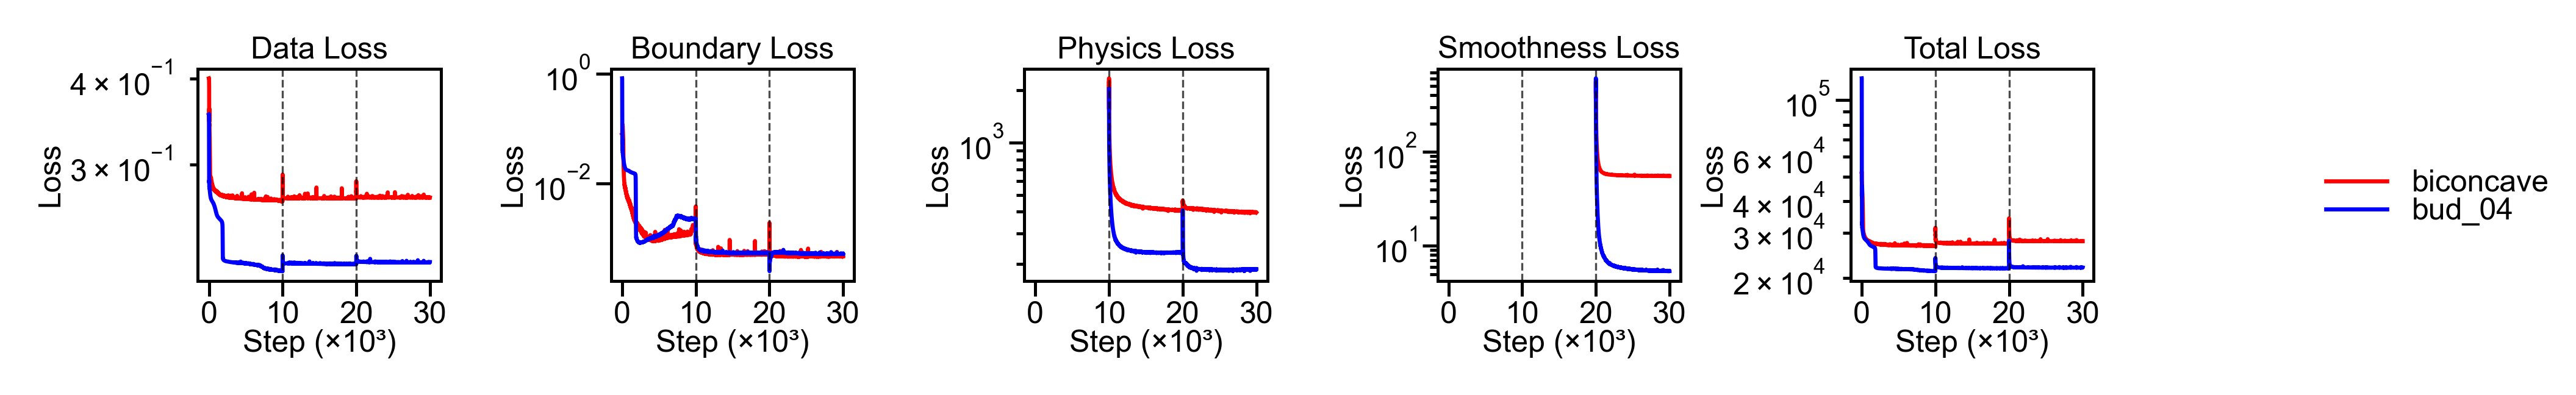

In [42]:
## FIGURE 2C (Loss Progress)
## Plot figures
from pinn.analysis import plot_loss_panels

plt.style.reload_library()
with plt.style.context(["base", "transparent"]):
    fig, axes = plot_loss_panels(assembled_loss, 
                                 shape_list,
                                 figsize=(7.0, 1),
                                 show_legend=True,
                                 smooth_window=3,
                                 logscale_keys=["data_loss", "sign_loss", "phys_loss", "curv_loss", "total_loss"],
                                )
    fig.subplots_adjust(bottom=0.3)  # try 0.30–0.45

    save_dir = f"../outputs/figs/v_0321/synth"
    os.makedirs(save_dir, exist_ok=True)
    # fig.savefig(f"{save_dir}/loss_prog_a{str_add}_m{str_miss}_g{GRID_SIZE}_l{lambda_1}-{lambda_2}-{lambda_3}-{lambda_4}.pdf", dpi=600, bbox_inches=None)
    plt.show(fig)

/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/data_0321/a010_m07_g128/phase0_100000_0_100000_0/checkpoint_0
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/data_0321/a010_m07_g128/phase0_100000_0_100000_0/checkpoint_200
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/data_0321/a010_m07_g128/phase0_100000_0_100000_0/checkpoint_1000
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/data_0321/a010_m07_g128/phase1_100000_1_100000_0/checkpoint_0
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/data_0321/a010_m07_g128/phase2_100000_1_100000_10/checkpoint_0
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/data_0321/a010_m07_g128/phase2_100000_1_100000_10/checkpoint_10000
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/bud_04/data_0321/a010_m07_g128/phase0_100000_0_100000_0/checkpoint_0
/mmfs1/gscratch/matsulab/sim/pinn

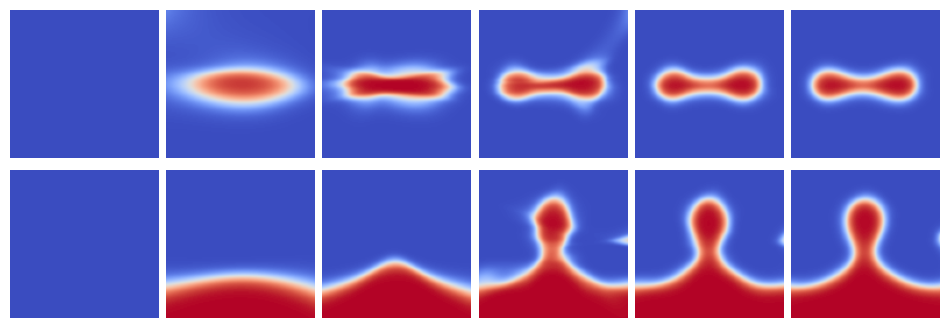

In [40]:
## FIGURE 2D (Phase Field Progress)

import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.plot import visualize_cryoET_with_contours, visualize_phase

import mrcfile
import jax
import jax.numpy as jnp

# ==== Parameters =====
GRID_SIZE = 128
lambda_1 = 100000
lambda_2 = 1
lambda_3 = 100000
lambda_4 = 10
shape_list = ["biconcave", "bud_04"]
step_list = [0, 200, 1000, 10000, 20000, 30000]
epsilon = 0.05
slice_index = 64
additive = 0.1
missing  = 0.7
str_add = f"{additive:.2f}".replace('.', '')
str_miss = f"{missing:.1f}".replace('.', '')
axis = "z"
ckpt = {}

# =========================
# Load checkpoints
# =========================
for shape in shape_list:
    ckpt[shape] = {}

    for step in step_list:

        if step < 10000:
            phase = 0
            _step = step
            _lambda_2 = 0
            _lambda_4 = 0
        
        elif step < 20000:
            phase = 1
            _step = step - 10000
            _lambda_2 = lambda_2
            _lambda_4 = 0
        
        elif step <= 30000:
            phase = 2
            _step = step - 20000
            _lambda_2 = lambda_2
            _lambda_4 = lambda_4
        
        else:
            raise ValueError(f"step out of range: {step}")

        checkpoint_dir = (
            f"../outputs/logs/{shape}/data_0321/"
            f"a{str_add}_m{str_miss}_g{GRID_SIZE}/"
            f"phase{phase}_{lambda_1}_{_lambda_2}_{lambda_3}_{_lambda_4}/"
            f"checkpoint_{_step}"
        )
        checkpoint_path = os.path.abspath(checkpoint_dir)
        print(checkpoint_path)

        checkpoint_data = checkpoints.restore_checkpoint(
            ckpt_dir=checkpoint_path,
            target=None
        )
        ckpt[shape][step] = checkpoint_data


# =========================
# Plot checkpoints
# =========================
n_col = len(step_list)
n_row = len(shape_list)

fig = plt.figure(figsize=(2 * n_col, 2 * n_row))
fig.subplots_adjust(wspace=0.05, hspace=0.08)

for row, shape in enumerate(shape_list):
    for col, step in enumerate(step_list):
        ax = fig.add_subplot(n_row, n_col, row * n_col + col + 1)

        checkpoint_data = ckpt[shape][step]

        visualize_phase(
            ax,
            epsilon=epsilon,
            checkpoint=checkpoint_data,
            component="phi",
            grid_size=GRID_SIZE,
            slice_index=slice_index,
            axis=axis,
            no_label=True,
            vmin=-1,
            vmax=1,
        )

save_dir = f"../outputs/figs/v_0321/synth"
os.makedirs(save_dir, exist_ok=True)

plt.savefig(f"{save_dir}/phi_prog_a{str_add}_m{str_miss}_g{GRID_SIZE}_l{lambda_1}-{lambda_2}-{lambda_3}-{lambda_4}.png", bbox_inches="tight", dpi=300)
plt.show()


/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/data_0321/a010_m07_g128/phase1_100000_1_100000_0/checkpoint_10000


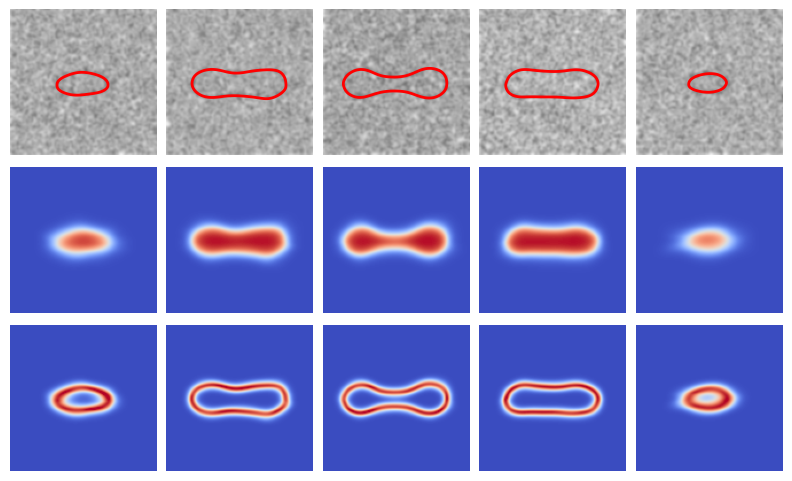

In [10]:
## FIGURE 2E (Phase Field Final Output)

import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.plot import visualize_cryoET_with_contours, visualize_phase

import mrcfile
import jax
import jax.numpy as jnp

# ==== Parameters =====
GRID_SIZE = 128
lambda_1 = 100000
lambda_2 = 1
lambda_3 = 100000
lambda_4 = 10
shape = "biconcave"
step = 10000
epsilon = 0.05
phase = 1

if phase == 0:
    _lambda_2 = 0
    _lambda_4 = 0
elif phase == 1:
    _lambda_2 = lambda_2
    _lambda_4 = 0
elif phase == 2:
    _lambda_2 = lambda_2
    _lambda_4 = lambda_4

extend_xy = None

additive = 0.1
missing  = 0.7
str_add = f"{additive:.2f}".replace('.', '')
str_miss = f"{missing:.1f}".replace('.', '')
slice_index_list = [24, 44, 64, 84, 104] 
axis = "z"

# ==== Load checkpoint data =====
checkpoint_dir = f"../outputs/logs/{shape}/data_0321/a{str_add}_m{str_miss}_g{GRID_SIZE}/phase{phase}_{lambda_1}_{_lambda_2}_{lambda_3}_{_lambda_4}/checkpoint_{step}"
checkpoint_path = os.path.abspath(checkpoint_dir)
print(checkpoint_path)
checkpoint_data = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# ==== Load CryoET data =====
mrc_file_path = f"../data/synthetic/mrc/{shape}_a{str_add}_m{str_miss}.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)

n_col = len(slice_index_list)
n_row = 3
fig = plt.figure(figsize=(2*n_col, 2*n_row))

fig.subplots_adjust(
    wspace=0.05,   # width space (fraction of axes)
    hspace=0.08,   # height space
)

plt.style.reload_library()
with plt.style.context(["base", "transparent"]):

    # Row 1: target with contour
    for i, slice_index in enumerate(slice_index_list):
        ax = fig.add_subplot(n_row, n_col, i+1)
        visualize_cryoET_with_contours(ax, step, checkpoint_data, cryoET_data, no_label = True,
                                       grid_size=GRID_SIZE, slice_index=slice_index, axis=axis, thresholding=False, expand_xy=extend_xy)

    # Row 2: phi
    for i, slice_index in enumerate(slice_index_list):
        ax = fig.add_subplot(n_row, n_col, 1*n_col+i+1)
        visualize_phase(ax, epsilon=epsilon, checkpoint=checkpoint_data, component="phi",
                        grid_size=GRID_SIZE, slice_index=slice_index, axis=axis, no_label=True, vmin=-1, vmax=1, expand_xy=extend_xy)

    # Row 3: edge
    for i, slice_index in enumerate(slice_index_list):

        ax = fig.add_subplot(n_row, n_col, 2*n_col+i+1)
        visualize_phase(ax, epsilon=epsilon, checkpoint=checkpoint_data, component="tension", 
                        grid_size=GRID_SIZE, slice_index=slice_index, axis=axis, no_label=True, vmin=0.0, vmax=1.0, expand_xy=extend_xy)


    save_path = f"../outputs/figs/v_0321/synth/{shape}_a{str_add}_m{str_miss}_g{GRID_SIZE}"
    os.makedirs(save_path, exist_ok=True)
    plt.savefig(f"{save_path}/phase{phase}_{lambda_1}_{_lambda_2}_{lambda_3}_{_lambda_4}.png", bbox_inches="tight")
    plt.show()


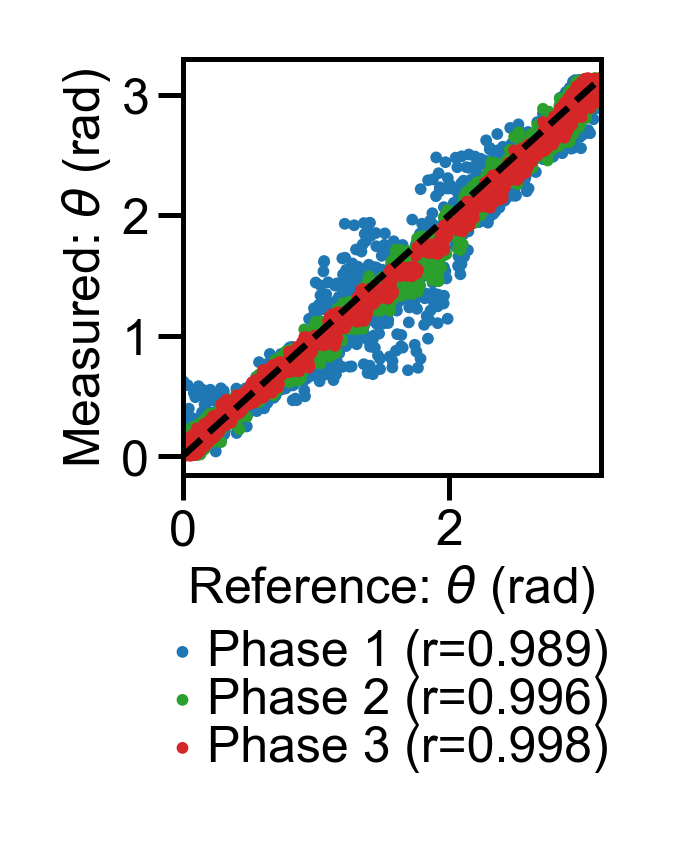

In [20]:
# FIGURE 2G (Quantification of Normal and Curvatures)

from pinn.normal_curves import load_mesh_npz, match_and_plot_multi_data
import matplotlib.pyplot as plt
import numpy as np
import os

# ==== Parameters =====
lambda_1 = 100000
lambda_2 = 1
lambda_3 = 100000
lambda_4 = 10
shape = "biconcave"
step = 10000
additive = 0.1
missing  = 0.7
grid_size = 128
str_add = f"{additive:.2f}".replace('.', '')
str_miss = f"{missing:.1f}".replace('.', '')
version  = "data_0321"
phase_list = [0, 1, 2]
figsize=(0.9, 0.9)
# figsize=(0.6, 0.9)
quantity = "theta"

save_path = f"../outputs/figs/v_0321/synth/{shape}_a{str_add}_m{str_miss}_g{grid_size}"
os.makedirs(save_path, exist_ok=True)

# ==== Load npz data =====
# GROUND TRUTH
npz_path = f"../data/synthetic/gt/relaxed_{shape}.npz"
verts_gt, faces_gt, norms_gt, theta_gt, curvs_gt, gauss_gt, force_gt = load_mesh_npz(npz_path)
force_gt = np.linalg.norm(force_gt, axis=1)

# PINN RESULTS
verts_pf = {}; theta_pf = {}; curvs_pf = {}; gauss_pf = {}; force_pf = {}
for phase in phase_list:
    if phase == 0:
        _lambda_2 = 0
        _lambda_4 = 0
    elif phase == 1:
        _lambda_2 = lambda_2
        _lambda_4 = 0
    elif phase == 2:
        _lambda_2 = lambda_2
        _lambda_4 = lambda_4
    checkpoint_dir = f"../outputs/logs/{shape}/{version}/a{str_add}_m{str_miss}_g{grid_size}"
    npz_path = f"{checkpoint_dir}/phase{phase}_{lambda_1}_{_lambda_2}_{lambda_3}_{_lambda_4}/verts_{step}.npz"
    verts, faces, norms, theta, curvs, gauss, force = load_mesh_npz(npz_path)
    force = np.linalg.norm(force, axis=1)
    verts_pf[phase] = verts; theta_pf[phase] = theta; curvs_pf[phase] = curvs; gauss_pf[phase] = gauss; force_pf[phase] = force


plt.style.reload_library()
with plt.style.context(["base", "transparent"]):

    if quantity == "theta":
        fig, _ = match_and_plot_multi_data(
                                verts_gt, theta_gt, 
                                B_datasets=[
                                    (verts_pf[0], theta_pf[0]),
                                    (verts_pf[1], theta_pf[1]),
                                    (verts_pf[2], theta_pf[2]),
                                ],
                                # xlabel="Angle: GT  (rad)",
                                # ylabel="Angle: PINN  (rad)",  
                                xlabel=r"Reference: $\theta$ (rad)",
                                ylabel=r"Measured: $\theta$ (rad)",
                                labels=["Phase 1", "Phase 2", "Phase 3"],
                                colors=["tab:blue", "tab:green", "tab:red"],
                                figsize=figsize,
                                xlim=(0, np.max(theta_gt)),
                               )
    elif quantity == "curvs":
        fig, _ = match_and_plot_multi_data(
                                verts_gt, curvs_gt, 
                                B_datasets=[
                                    (verts_pf[0], curvs_pf[0]),
                                    (verts_pf[1], curvs_pf[1]),
                                    (verts_pf[2], curvs_pf[2]),
                                ],
                                # xlabel=r"$H$: GT  (1/$\sigma$)",
                                # ylabel=r"$H$: PINN  (1/$\sigma$)",
                                xlabel=r"Reference: $H$ (1/$\sigma$)",
                                ylabel=r"Measured: $H$ (1/$\sigma$)",
                                labels=["Phase 1", "Phase 2", "Phase 3"],
                                colors=["tab:blue", "tab:green", "tab:red"],
                                figsize=figsize,
                                xlim=(np.min(curvs_gt), np.max(curvs_gt)),
                               )    
    elif quantity == "gauss":
        fig, _ = match_and_plot_multi_data(
                                verts_gt, gauss_gt, 
                                B_datasets=[
                                    (verts_pf[0], gauss_pf[0]),
                                    (verts_pf[1], gauss_pf[1]),
                                    (verts_pf[2], gauss_pf[2]),
                                ],
                                # xlabel=r"$G$: GT  (1/$\sigma$)",
                                # ylabel=r"$G$: PINN  (1/$\sigma$)",
                                xlabel=r"Reference: $G$ (1/$\sigma$)",
                                ylabel=r"Measured: $G$ (1/$\sigma$)",
                                labels=["Phase 1", "Phase 2", "Phase 3"],
                                colors=["tab:blue", "tab:green", "tab:red"],
                                figsize=figsize,
                                xlim=(np.min(gauss_gt), np.max(gauss_gt)),
                               )
    elif quantity == "force":
        fig, _ = match_and_plot_multi_data(
                                verts_gt, force_gt, 
                                B_datasets=[
                                    (verts_pf[0], force_pf[0]),
                                    (verts_pf[1], force_pf[1]),
                                    (verts_pf[2], force_pf[2]),
                                ],
                                xlabel=r"Force: GT  ()",
                                ylabel=r"Force: PINN  ()",
                                labels=["Phase 1", "Phase 2", "Phase 3"],
                                colors=["tab:blue", "tab:green", "tab:red"],
                                figsize=figsize,
                                xlim=(np.min(force_gt), np.max(force_gt)),
                               )
    
    fig.savefig(f"{save_path}/cor_{quantity}_l{lambda_1}-{lambda_2}-{lambda_3}-{lambda_4}.pdf", bbox_inches="tight")
    plt.show()

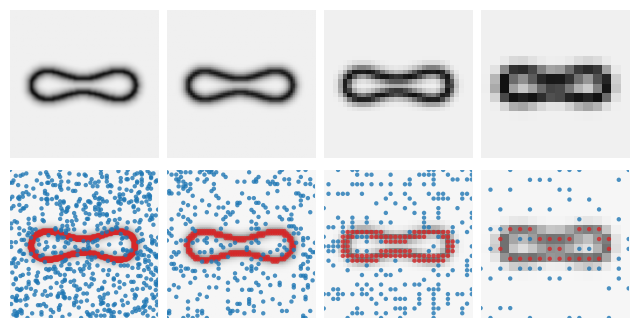

In [91]:
## FIGURE 3A (Input Images, Comparison of Noise)

import os
import numpy as np
import matplotlib.pyplot as plt
from pinn.cryoet_io import load_mrc_data
from data_generation.preprocess import overlay_points_on_cryoet_ax
from pinn.utils import load_pts_data

import mrcfile
import jax
import jax.numpy as jnp

# ==== Parameters =====
GRID_SIZE = 128
shape = "biconcave"
additive = 0.1
# missing_list  = [0.0, 0.6, 0.7, 0.8]
missing = 0.0
axis = "z"
# grid_size = 128
grid_size_list = [128, 64, 32, 16]
pts_size = 10
lambda_1 = 100000
lambda_2 = 1
lambda_3 = 100000

n_col = len(missing_list)
n_row = 2
fig = plt.figure(figsize=(2*n_col, 2*n_row))

fig.subplots_adjust(
    wspace=0.05,   # width space (fraction of axes)
    hspace=0.08,   # height space
)

plt.style.reload_library()
with plt.style.context(["base", "transparent"]):

    # for i, missing in enumerate(missing_list):
    for i, grid_size in enumerate(grid_size_list):
        
        if missing == 0.0:
            _additive = 0.0
        else:
            _additive = additive
        str_add  = f"{_additive:.2f}".replace('.', '')
        str_miss = f"{missing:.1f}".replace('.', '')

        # ==== Load point data =====
        pts_path = f"../data/synthetic/pts/"
        edge = load_pts_data(f"{pts_path}/edge/e_{shape}_a{str_add}_m{str_miss}_g{grid_size}.npz", perm=(0,1,2))
        pt_e = edge["points"][edge["label"] == 1][:, [2, 0, 1]]
        pt_b = edge["points"][edge["label"] == 0][:, [2, 0, 1]]
        overlay_edge = [
            {"data": pt_e, "label": "Edge", "color": "tab:red"},
            {"data": pt_b, "label": "Bulk", "color": "tab:blue"},
        ]
        
        # ==== Load CryoET data =====
        mrc_file_path = f"../data/synthetic/mrc/{shape}_a{str_add}_m{str_miss}.mrc"
        cryoET_data = load_mrc_data(mrc_file_path, grid_size=grid_size)
        
        ax = fig.add_subplot(2, n_col, i+1)
        overlay_points_on_cryoet_ax(ax, cryoet=cryoET_data, axis=axis, slice_index=grid_size//2)

        ax = fig.add_subplot(2, n_col, 1*n_col+i+1)
        overlay_points_on_cryoet_ax(ax, cryoet=cryoET_data, overlays=overlay_edge, axis=axis, slice_index=grid_size//2, pts_size=pts_size, cryo_alpha=0.6)
    
    # plt.savefig(f"../outputs/figs/v_0321/synth/noise-additive/input-{shape}.png", bbox_inches="tight")
    # plt.savefig(f"../outputs/figs/v_0321/synth/noise-sparse/input-{shape}.png", bbox_inches="tight")
    plt.show()

In [2]:
## FIGURE 3C (Noise vs Metric)
## Load data

import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.analysis import surface_dice
from pinn.normal_curves import match_nearest_neighbor, load_mesh_npz

# ==== Parameters =====
lambda_1 = 100000
lambda_2 = 1
lambda_3 = 100000
lambda_4 = 10
shape_list = ["biconcave", "bud_04"]
# missing_list  = [0.0, 0.6, 0.7, 0.8]
missing = 0.0
additive = 0.1
version  = "data_0321"
GRID_SIZE = 128
# grid_size = 128
grid_size_list = [128, 64, 32, 16]
step = 10000
phase_list = [0,1,2]


dice = {}; theta_cor = {}; curvs_cor = {}; gauss_cor = {}

for shape in shape_list:
    mrc_path = f"../data/synthetic/mrc/{shape}_a000_m00.mrc"
    npz_path = f"../data/synthetic/gt/relaxed_{shape}.npz"
    verts_gt, _, _, theta_gt, curvs_gt, gauss_gt, _ = load_mesh_npz(npz_path)
    dice[shape] = {}; theta_cor[shape] = {}; curvs_cor[shape] = {}; gauss_cor[shape] = {}
    
    for phase in phase_list:
        dice[shape][phase] = {}; theta_cor[shape][phase] = {}; curvs_cor[shape][phase] = {}; gauss_cor[shape][phase] = {}
        if phase == 0:
            _lambda_2 = 0
            _lambda_4 = 0
        elif phase == 1:
            _lambda_2 = lambda_2
            _lambda_4 = 0
        elif phase == 2:
            _lambda_2 = lambda_2
            _lambda_4 = lambda_4
        
        # for missing in missing_list:
        for grid_size in grid_size_list:
            if missing == 0.0:
                _additive = 0.00
            else:
                _additive = additive
    
            str_add = f"{_additive:.2f}".replace('.', '')
            str_miss = f"{missing:.1f}".replace('.', '')
            
            root_dir = f"../outputs/logs/{shape}/{version}/a{str_add}_m{str_miss}_g{grid_size}"
            data_dir = os.path.abspath(f"{root_dir}/phase{phase}_{lambda_1}_{_lambda_2}_{lambda_3}_{_lambda_4}")
            ckpt_dir = os.path.join(data_dir, f"checkpoint_{step}")
            ckpt_dat = checkpoints.restore_checkpoint(ckpt_dir=ckpt_dir, target=None)
            print(data_dir)

            # dice[shape][phase][missing] = surface_dice(mrc_path, ckpt_dat, grid_size=GRID_SIZE, threshold=0.6, band_thickness=0.4)
            dice[shape][phase][grid_size] = surface_dice(mrc_path, ckpt_dat, grid_size=GRID_SIZE, threshold=0.6, band_thickness=0.4)
    
            npz_path = f"{data_dir}/verts_{step}.npz"
            verts, _, _, theta, curvs, gauss, _ = load_mesh_npz(npz_path)
    
            # theta_cor[shape][phase][missing] = match_nearest_neighbor(verts_gt, theta_gt, verts, theta)
            # curvs_cor[shape][phase][missing] = match_nearest_neighbor(verts_gt, curvs_gt, verts, curvs)
            # gauss_cor[shape][phase][missing] = match_nearest_neighbor(verts_gt, gauss_gt, verts, gauss)

            theta_cor[shape][phase][grid_size] = match_nearest_neighbor(verts_gt, theta_gt, verts, theta)
            curvs_cor[shape][phase][grid_size] = match_nearest_neighbor(verts_gt, curvs_gt, verts, curvs)
            gauss_cor[shape][phase][grid_size] = match_nearest_neighbor(verts_gt, gauss_gt, verts, gauss)


/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/data_0321/a000_m00_g128/phase0_100000_0_100000_0


W0331 21:54:30.039171    7541 gemm_fusion_autotuner.cc:1050] Compiling 4 configs for gemm_fusion_dot_general.1 on a single thread.
W0331 21:54:30.602319    7541 gemm_fusion_autotuner.cc:1050] Compiling 9 configs for gemm_fusion_dot_general.1 on a single thread.
W0331 21:54:31.843502    7541 gemm_fusion_autotuner.cc:1050] Compiling 13 configs for gemm_fusion_dot.1 on a single thread.


/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/data_0321/a000_m00_g64/phase0_100000_0_100000_0
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/data_0321/a000_m00_g32/phase0_100000_0_100000_0
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/data_0321/a000_m00_g16/phase0_100000_0_100000_0
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/data_0321/a000_m00_g128/phase1_100000_1_100000_0
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/data_0321/a000_m00_g64/phase1_100000_1_100000_0
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/data_0321/a000_m00_g32/phase1_100000_1_100000_0
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/data_0321/a000_m00_g16/phase1_100000_1_100000_0
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/data_0321/a000_m00_g128/phase2_100000_1_100000_10
/mmfs1/gscrat

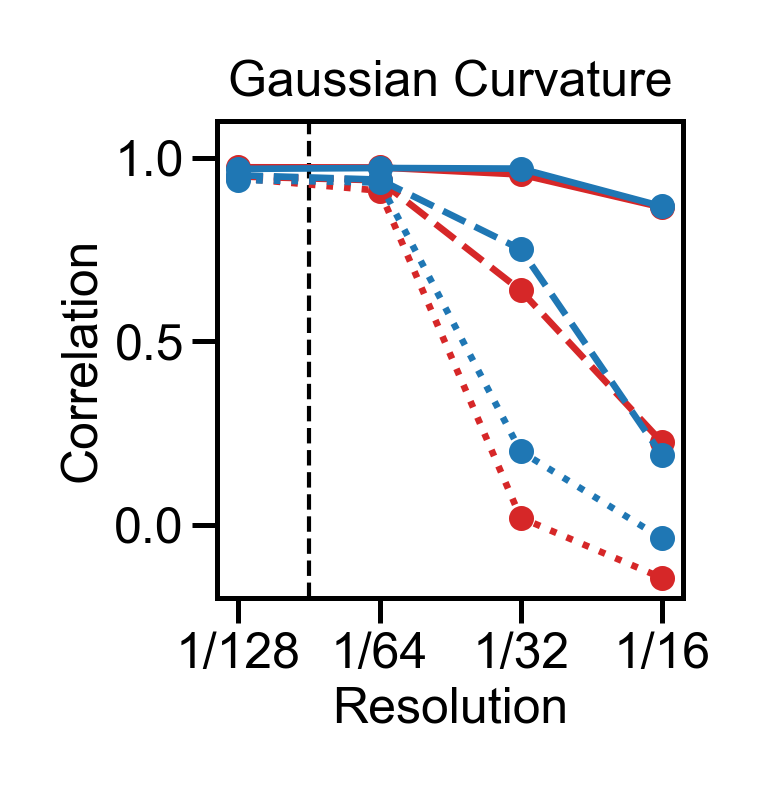

In [13]:
from pinn.normal_curves import plot_ablation

figsize = (1.3,1.3)


# save_path = "../outputs/figs/v_0321/synth/noise-additive"
# xtick_labels=None
# xlabel="Noise Level"
# x_values=missing_list

save_path = "../outputs/figs/v_0321/synth/noise-sparse"
xtick_labels=["1/128", "1/64", "1/32", "1/16"]
xlabel="Resolution"
x_values=grid_size_list

plt.style.reload_library()
with plt.style.context(["base", "transparent"]):

    # plot_ablation(
    #     dice,
    #     shape_list=shape_list,
    #     phase_list=phase_list,
    #     x_values=x_values,
    #     xlabel=xlabel,
    #     ylabel="Dice Score",
    #     title="Surface Dice",
    #     figsize=figsize,
    #     show_legend=False,
    #     ylim=(-0.1,1.1),
    #     gap_after_first=True,
    #     xtick_labels=xtick_labels,
    #     save_path=f"{save_path}/dice.pdf",
    #     # save_path=f"{save_path}/legend.pdf"
    # )
    
    # plot_ablation(
    #     theta_cor,
    #     shape_list=shape_list,
    #     phase_list=phase_list,
    #     x_values=x_values,
    #     xlabel=xlabel,
    #     ylabel="Correlation",
    #     title="Normal Angle",
    #     figsize=figsize,
    #     show_legend=False,
    #     ylim=(-0.1,1.1),
    #     gap_after_first=True,
    #     xtick_labels=xtick_labels,
    #     save_path=f"{save_path}/theta.pdf",
    # )
    
    # plot_ablation(
    #     curvs_cor,
    #     shape_list=shape_list,
    #     phase_list=phase_list,
    #     x_values=x_values,
    #     xlabel=xlabel,
    #     ylabel="Correlation",
    #     title="Mean Curvature",
    #     figsize=figsize,
    #     show_legend=False,
    #     ylim=(-0.1,1.1),
    #     gap_after_first=True,  
    #     xtick_labels=xtick_labels,
    #     save_path=f"{save_path}/curvs.pdf"
    # )
        
    plot_ablation(
        gauss_cor,
        shape_list=shape_list,
        phase_list=phase_list,
        x_values=x_values,
        xlabel=xlabel,
        ylabel="Correlation",
        title="Gaussian Curvature",
        figsize=figsize,
        show_legend=False,
        # ylim=(-0.1,1.1),
        ylim=(-0.2,1.1),
        gap_after_first=True,
        xtick_labels=xtick_labels,
        save_path=f"{save_path}/gauss.pdf"
    )

In [5]:
## To reload

import importlib
# import pinn.plot as plot
# import data_generation.preprocess as preprocess
# import pinn.utils as utils
# import pinn.analysis as analysis
import pinn.normal_curves as normal_curves

# importlib.reload(plot)
# importlib.reload(utils)
# importlib.reload(preprocess)
# importlib.reload(analysis)
importlib.reload(normal_curves)

<module 'pinn.normal_curves' from '/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/notebooks/../src/pinn/normal_curves.py'>

In [8]:
print(gauss_cor)
print(curvs_cor)

{0: {0.0: 0.9244818885402216, 0.6: 0.8535116177619742, 0.7: 0.6465199750764272, 0.8: 0.49500322786870626, 0.9: 0.18860733510253283}, 10: {0.0: 0.9009007383677825, 0.6: 0.910460662216215, 0.7: 0.857685975579007, 0.8: 0.8762844237287911, 0.9: 0.7310608682144887}}
{0: {0.0: 0.9171896169116767, 0.6: 0.8392043833904753, 0.7: 0.6797124713365718, 0.8: 0.5679632324479695, 0.9: 0.19767679659891413}, 10: {0.0: 0.8925097725494212, 0.6: 0.899859829733756, 0.7: 0.8527740642529489, 0.8: 0.8649522237751068, 0.9: 0.7114996349772}}
